In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from transformers import AutoTokenizer
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import confusion_matrix
from collections import OrderedDict
import shap
import re

import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import balanced_accuracy_score, accuracy_score
from tqdm import tqdm

from models.t0 import T0RegressionModel
from datahandles import MetaDatasetBuilder, FewShotDataset
from utils import Config, ConfigObject, dict_to_mlp

os.environ["HF_HOME"] = "/export/pasan/.cache/huggingface"
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

/afs/glue.umd.edu/home/glue/p/a/pasand/home/miniconda3/envs/transhyper2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
checkpoint_path = f"save/t0pp-selfSameQueries-calhousing/epoch-last.pth"
checkpoint = torch.load(checkpoint_path, weights_only=False)
cfg = Config(cfg_dict=checkpoint["cfg"])
model = T0RegressionModel(cfg=cfg)
model.load_state_dict(checkpoint['model'])
tokenizer = AutoTokenizer.from_pretrained(cfg.tokenizer.model())

RuntimeError: PytorchStreamReader failed reading zip archive: failed finding central directory

In [3]:
vals_to_print = {
    '# shots': cfg.datasets.n_shots(),
    '# queries': cfg.datasets.n_queries(),
    '# meta examples': cfg.datasets.train_size(),
    'total training set size': cfg.datasets.n_shots() * cfg.datasets.train_size() if cfg.datasets.queries_same_as_shots() else (cfg.datasets.n_queries() + cfg.datasets.n_shots()) * cfg.datasets.train_size(),
    'queries same as shots?': cfg.datasets.queries_same_as_shots(),
    'with random permutations?': cfg.datasets.train_permutation()
}

print(f"training setup:")
for key, val in vals_to_print.items():
    print(f"{key}: {val}")


NameError: name 'cfg' is not defined

# Utils

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names=None, normalize=False, cmap='Blues'):
    """
    Displays a confusion matrix.

    Parameters:
    - y_true: list or array of true labels
    - y_pred: list or array of predicted labels
    - class_names: list of class names (optional)
    - normalize: whether to normalize the matrix (default: False)
    - cmap: color map for the heatmap
    """
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap=cmap,
                xticklabels=class_names if class_names else 'auto',
                yticklabels=class_names if class_names else 'auto')
    
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix' + (' (Normalized)' if normalize else ''))
    plt.tight_layout()
    plt.show()

In [6]:
def load_test_dataset(
                  test_list: list,
                  n_shots:int,
                  n_queries:int,
                  train_size:int = 1, 
                  test_size:int = 1,
                  balanced:dict = None, 
                  train_permutation:list | bool = True,
                  test_permutation:list | bool = False,
                  max_n_features:int = 103
                ):
    if balanced is None:
        balanced = {'train': True, 'val': False, 'test': False}
    train_list = test_list
    # meta_dataset = MetaDatasetBuilder(data_root="./data",
    #                                   train_datasets=train_list,
    #                                   val_datasets=train_list,
    #                                   test_datasets=test_list,
    #                                   train_size=train_size,
    #                                   test_size=test_size,
    #                                   val_size=train_size,
    #                                   train_permutation=train_permutation,
    #                                   test_permutation=test_permutation,
    #                                   val_permutation=train_permutation,
    #                                   train_balance=balanced["train"],
    #                                   val_balance=balanced["val"],
    #                                   test_balance=balanced["test"],
    #                                   n_shots=n_shots,
    #                                   n_queries=n_queries,
    #                                   max_n_features=103,
    #                                   shuffle=True,
    #                                   queries_same_as_shots=True,
    #                                   debug=False,
    #                                   shots_with_labels={'train': True, 'val': True, 'test': False}
    #                                   ).get_datasets()

    train_ds = FewShotDataset(
        dataset_names=test_list,
        data_root=cfg.datasets.data_root(),
        split='train',
        split_size=1,
        n_shots=n_shots,
        n_queries=cfg.datasets.n_queries(),
        queries_same_as_shots=cfg.datasets.queries_same_as_shots(),
        max_n_features=max_n_features,
        balance_labels=True, ############################################# see why cfg is not working
        col_permutation=False,
        shuffle=False,
        debug=False,
        shots_with_labels=True
    )

    test_ds = FewShotDataset(
        dataset_names=test_list,
        data_root=cfg.datasets.data_root(),
        split='test',
        split_size=test_size,
        n_shots=n_shots,
        n_queries=n_queries,
        queries_same_as_shots=True,
        max_n_features=max_n_features,
        balance_labels=False,
        col_permutation=False,
        shuffle=True,
        debug=False,
        shots_with_labels=True
    )
    
    # print(f"dataset length: {len(meta_dataset['test'])}, # queries: {len(meta_dataset['test'][0]['queries_y'])}")
    # return meta_dataset["test"], meta_dataset["train"]
    return test_ds, train_ds

def get_hyponet(prompt):
    if len(prompt) < 1:
        prompt = "Quick brown fox jumped over the lazy dog!"
        
    tokens = tokenizer(prompt, 
                    truncation=cfg.tokenizer.truncation(), 
                    padding=cfg.tokenizer.padding(), 
                    max_length=cfg.tokenizer.max_length(), 
                    return_tensors='pt')
    return model(tokens)

# Hyponet evaluate

In [7]:
def compute_metrics(prompt, X, y):
    hyponet = get_hyponet(prompt=prompt)
    hyponet.eval()
    preds = hyponet.forward(torch.Tensor(X).unsqueeze(dim=0))
    preds = preds.detach().numpy()
    preds = np.squeeze(preds)
    y_pred = np.argmax(preds, axis=1)

    val_counts = pd.DataFrame(y).value_counts()
    const_pred_acc = max(val_counts)/sum(val_counts)
    balanced_acc = balanced_accuracy_score(y, y_pred)
    unbalanced_acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, preds[:,1])

    return {
        "const_predictor_acc": const_pred_acc,
        "balanced_acc": balanced_acc,
        "unbalanced_acc": unbalanced_acc,
        "f1_score": f1,
        "roc_auc": roc_auc
    }

def compute_avg_metrics(ds_name, n_shots, n_queries, n_samples):
    test_ds, train_ds = load_test_dataset(test_list=[ds_name],
                                n_shots=n_shots,
                                n_queries=n_queries,
                                test_size=n_samples,
                               )
    avg_metrics = {}
    for i in range(n_samples):
        prompt = test_ds[0]['shots']
        X = test_ds[i]['queries_x']
        y = test_ds[i]['queries_y']
        metrics = compute_metrics(prompt=prompt, X=X, y=y)
        for key, val in metrics.items():
            if key in avg_metrics.keys():
                avg_metrics[key] += val
            else:
                avg_metrics[key] = val

    avg_metrics = {key: val / n_samples for key, val in avg_metrics.items()}
    return avg_metrics

In [8]:
ds_name = 'calhousing'
n_samples = 1
n_queries = 2000
# n_shots_list = [0, 4, 8, 16, 32, 64, 128, 256]
n_shots_list = [8, 10, 64]
# n_shots_list = [0, 1]

balanced_acc = []
unbalanced_acc = []
f1 = []
roc_auc = []
for n_shots in n_shots_list:
    metrics = compute_avg_metrics(ds_name=ds_name, n_shots=n_shots, n_queries=n_queries, n_samples=n_samples)
    balanced_acc.append(metrics['balanced_acc'])
    unbalanced_acc.append(metrics['unbalanced_acc'])
    f1.append(metrics['f1_score'])
    roc_auc.append(metrics['roc_auc'])

NameError: name 'cfg' is not defined

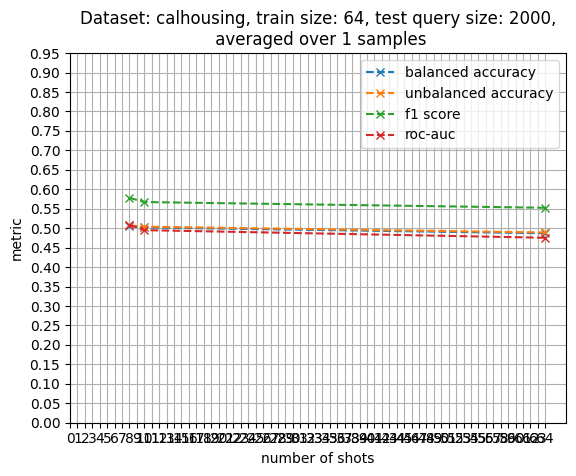

all values: {8: 0.5091375559500888, 10: 0.49501587857267887, 64: 0.4754469755695031}
max values:
balanced acc 0.51 at 8 shots
unbalanced acc 0.51 at 8 shots
f1 score 0.58 at 8 shots
roc-auc 0.51 at 8 shots


In [ ]:
plt.plot(n_shots_list, balanced_acc, 'x--', label="balanced accuracy")
plt.plot(n_shots_list, unbalanced_acc, 'x--', label="unbalanced accuracy")
plt.plot(n_shots_list, f1, 'x--', label='f1 score')
plt.plot(n_shots_list, roc_auc, 'x--', label='roc-auc')
plt.title(f"Dataset: {ds_name}, train size: {vals_to_print['total training set size']}, test query size: {n_queries},\n averaged over {n_samples} samples")
plt.xlabel("number of shots")
plt.ylabel("metric")
plt.xticks(ticks=range(max(n_shots_list)+1))
plt.yticks(ticks=np.arange(0, 1, 0.05))
plt.grid(visible=True, which='both')
plt.legend()
plt.show()

b_acc_max_idx = np.argmax(balanced_acc, axis=0)
ub_acc_max_idx = np.argmax(unbalanced_acc, axis=0)
f1_max_idx = np.argmax(f1, axis=0)
roc_auc_max_idx = np.argmax(roc_auc, axis=0)
print("all values:", {n_shots_list[i]: roc_auc[i] for i in range(len(n_shots_list))})
print("max values:")
print(f"balanced acc {balanced_acc[b_acc_max_idx]:.2} at {n_shots_list[b_acc_max_idx]} shots")
print(f"unbalanced acc {unbalanced_acc[ub_acc_max_idx]:.2} at {n_shots_list[ub_acc_max_idx]} shots")
print(f"f1 score {f1[f1_max_idx]:.2} at {n_shots_list[f1_max_idx]} shots")
print(f"roc-auc {roc_auc[roc_auc_max_idx]:.2} at {n_shots_list[roc_auc_max_idx]} shots")